
#MVP: *Machine Learning & Analytics*

Modelo de Classificação de Dados Geotécnicos por *Random Forest* e *K-Means*

**Autor:** Felipe Barreto R. S. Macedo

**Data:** 05/07/2026

**Matrícula:** XXXXX

**Dataset:** Ex: Global Dataset of Cone Penetration Test Results - Jianye Ching (http://140.112.12.21/issmge/Database/Global_CPT_3_1196/Global_CPT_3_1196.zip)


---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

A classificação de tipos de solo é de fundamental importância para a Engenharia Geotécnica, sendo o ensaio de Penetração de Cone Piezométrico (CPT) uma das formas mais confiáveis de obtenção de dados subterrâneos, em particular para projetos submarinos.

O resultado do CPT fornece parâmetros que permitem avaliar granulometria do solo e calcular valores de resistência ao cisalhamento. Usualmente, é utilizado o método empírico de Robertson para classificação de solos (Soil Behavior Type), embora esse modelo seja generalista, muitas vezes não permitindo a avaliação de mudanças de comportamento local.

A proposta desse MVP é a criação de modelos que permitam:
- classificar camadas de solo a partir dos parâmetros do CPT;
- detecte interfaces em camadas;
- comparar com o modelo de Robertson, avaliando concordâncias, discordâncias e abrangência.

Para tanto, foi utilizado um dataset de resultados globais de CPT disponibilizado na internet. Os dados estão divididos por locação, organizados em planilhas .xlsx, e apresentam os parâmetros usuais de resultados de CPT:
- depth - Profundidade (m)
- qc - Resistência de ponta (MPa)
- fs - Atrito lateral (kPa)
- u2 - Poropressão (kPa)

Foram previstas as seguintes etapas:
1. Pré-processamento com compilação, padronização e normalização dos dados.
2. *Feature Engineering* com cálculo das tensões in-situ e dos índices normalizados.
3. Classificação supervisionada pelo modelo de Robertson (parâmetro Ic), servindo de base para a comparação dos modelos.
4. Modelagem não supervisionada por K-Means, com escolha de k por meio do Silhouette Score e método do cotovelo.
5. Modelagem por Random Forest supervisionada pelo método de Robertson, possibilitando predição e indicando a importância de cada feature.
6. Comparação entre K-Means, Random Forest e Robertson.

Como resultado, proponho um log CPT classificado para furos de teste, acompanhado de uma tabela de métricas comparando os dois modelos com Robertson — permitindo avaliar quantitativamente o quanto a classificação automática converge ou diverge do método tradicional.





## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [ ]:
# ---- CÓDIGO REAL ----------#
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso.')

In [ ]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 42



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


2.1.a Instalações

In [ ]:
!pip install openpyxl -q

2.1.a Bibliotecas

In [ ]:
import pandas as pd
import os
import shutil
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.


## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


Clonagem de Repositório

In [4]:
try:
    import google.colab
    COLAB = True
except ImportError:
    COLAB = False

REPO_URL = 'https://github.com/felipebrsm/PUC_Sprint_1_ML-FBRSM.git'

if COLAB:
    # Remove a pasta antiga e clona sempre do zero
    if os.path.exists('cpt-sbt-mvp'):
        shutil.rmtree('cpt-sbt-mvp')
    !git clone {REPO_URL} cpt-sbt-mvp -q
    print('Repositório clonado.')
    BASE = Path('cpt-sbt-mvp')
else:
    BASE = Path('..').resolve()

RAW_DIR       = BASE / 'data' / 'raw'
PROCESSED_DIR = BASE / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'Ambiente       : {"Google Colab" if COLAB else "Local"}')
print(f'Pasta raw      : {RAW_DIR}')
print(f'Pasta processed: {PROCESSED_DIR}')

Repositório clonado.
Ambiente       : Google Colab
Pasta raw      : cpt-sbt-mvp/data/raw
Pasta processed: cpt-sbt-mvp/data/processed


Ajustes nas Colunas

In [5]:
COLUNAS_PADRAO = {
    # profundidade
    'Depth(m)': 'depth', 'Depth': 'depth', 'depth': 'depth', 'z': 'depth',
    # resistência de ponta
    'Cone resistance, qc(MPa)': 'qc', 'qc': 'qc', 'Qc': 'qc', 'QC': 'qc',
    # atrito lateral
    'Sleeve friction, fs(kPa)': 'fs', 'fs': 'fs', 'Fs': 'fs', 'FS': 'fs',
    # pressão de poro
    'Pore pressure, u2(kPa)': 'u2', 'u2': 'u2', 'U2': 'u2',
}

COLUNAS_NECESSARIAS = ['depth', 'qc', 'fs', 'u2']

# Arquivos a ignorar (case-insensitive)
IGNORAR = ['cpt locations']

Leitura das Pastas com Dados

In [6]:
import os

# Lista o que existe dentro do repositório clonado
for raiz, pastas, arquivos in os.walk('cpt-sbt-mvp'):
    print(raiz)

cpt-sbt-mvp
cpt-sbt-mvp/.git
cpt-sbt-mvp/.git/objects
cpt-sbt-mvp/.git/objects/info
cpt-sbt-mvp/.git/objects/pack
cpt-sbt-mvp/.git/logs
cpt-sbt-mvp/.git/logs/refs
cpt-sbt-mvp/.git/logs/refs/remotes
cpt-sbt-mvp/.git/logs/refs/remotes/origin
cpt-sbt-mvp/.git/logs/refs/heads
cpt-sbt-mvp/.git/branches
cpt-sbt-mvp/.git/hooks
cpt-sbt-mvp/.git/info
cpt-sbt-mvp/.git/refs
cpt-sbt-mvp/.git/refs/remotes
cpt-sbt-mvp/.git/refs/remotes/origin
cpt-sbt-mvp/.git/refs/tags
cpt-sbt-mvp/.git/refs/heads
cpt-sbt-mvp/notebook
cpt-sbt-mvp/data
cpt-sbt-mvp/data/processed
cpt-sbt-mvp/data/raw
cpt-sbt-mvp/data/raw/Leiden
cpt-sbt-mvp/data/raw/@Port Nelson
cpt-sbt-mvp/data/raw/MudIsland
cpt-sbt-mvp/data/raw/@Aranui
cpt-sbt-mvp/data/raw/@Lower Hutt (town hall)
cpt-sbt-mvp/data/raw/Wufeng
cpt-sbt-mvp/data/raw/@Ferrymead (sweet water place)
cpt-sbt-mvp/data/raw/@Marshland
cpt-sbt-mvp/data/raw/St.Louis
cpt-sbt-mvp/data/raw/Yuanlin
cpt-sbt-mvp/data/raw/MarkerTree
cpt-sbt-mvp/data/raw/TreasureIsland
cpt-sbt-mvp/data/raw

Resumo do Dataset

In [9]:
if not dfs:
    raise RuntimeError('Nenhum dado carregado. Verifique a estrutura de pastas e nomes de colunas.')

dataset = pd.concat(dfs, ignore_index=True)

print('=' * 50)
print('RESUMO DO DATASET COMPILADO')
print('=' * 50)
print(f'Linhas totais  : {len(dataset):,}')
print(f'Locações       : {dataset["locacao"].nunique()}')
print(f'Ensaios únicos : {dataset[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Abas únicas    : {dataset[["locacao","ensaio","pagina"]].drop_duplicates().shape[0]}')
print()
print('Ensaios por locação:')
print(dataset.groupby('locacao')['ensaio'].nunique().to_string())

RESUMO DO DATASET COMPILADO
Linhas totais  : 475,083
Locações       : 23
Ensaios únicos : 412
Abas únicas    : 412

Ensaios por locação:
locacao
@Aranui                                   11
@Avondale                                 33
@Avonside                                 12
@Bexley                                   14
@Camberley (hospital)                     12
@Cashmere (high school)                   16
@Christchurch (Central City)              36
@Christchurch (Cnr Armagh & Durham St)     6
@Christchurch (Metro Sports Facility)     15
@Christchurch (stadium)                   12
@Hastings (hospital)                      13
@Lower Hutt (town hall)                   29
@Marshland                                24
@Marshland (road)                         27
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Parkland (Bower Ave)TWO                  11
@Port Nelson                              27
@Redcliffs (Main road)                     7


Estatísticas

In [10]:
print('ESTATÍSTICAS DESCRITIVAS')
print(dataset[['depth','qc','fs','u2']].describe().round(3))
print()
print('VALORES NULOS')
nulos = dataset.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')
print()
dataset.head()

ESTATÍSTICAS DESCRITIVAS
            depth          qc          fs           u2
count  475083.000  475083.000  472984.000   475083.000
mean        8.814       9.561      76.103      194.899
std         6.965       9.088     167.652    35535.280
min         0.000      -0.249   -7777.000   -90470.000
25%         3.487       2.140      27.700      -20.500
50%         6.993       6.950      56.500       14.000
75%        12.735      14.777      99.700       72.000
max       824.000      94.360    1674.000  9999000.000

VALORES NULOS
fs    2099
dtype: int64



,locacao,ensaio,pagina,depth,qc,fs,u2
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9


Exportação

In [16]:
OUTPUT = PROCESSED_DIR / 'dataset_compilado.csv'
dataset.to_csv(OUTPUT, index=False)
print(f'Exportado para : {OUTPUT}')
print(f'Tamanho        : {OUTPUT.stat().st_size / 1024:.1f} KB')

Exportado para : cpt-sbt-mvp/data/processed/dataset_compilado.csv
Tamanho        : 35279.6 KB


Balanceamento

Shape: (475083, 7)


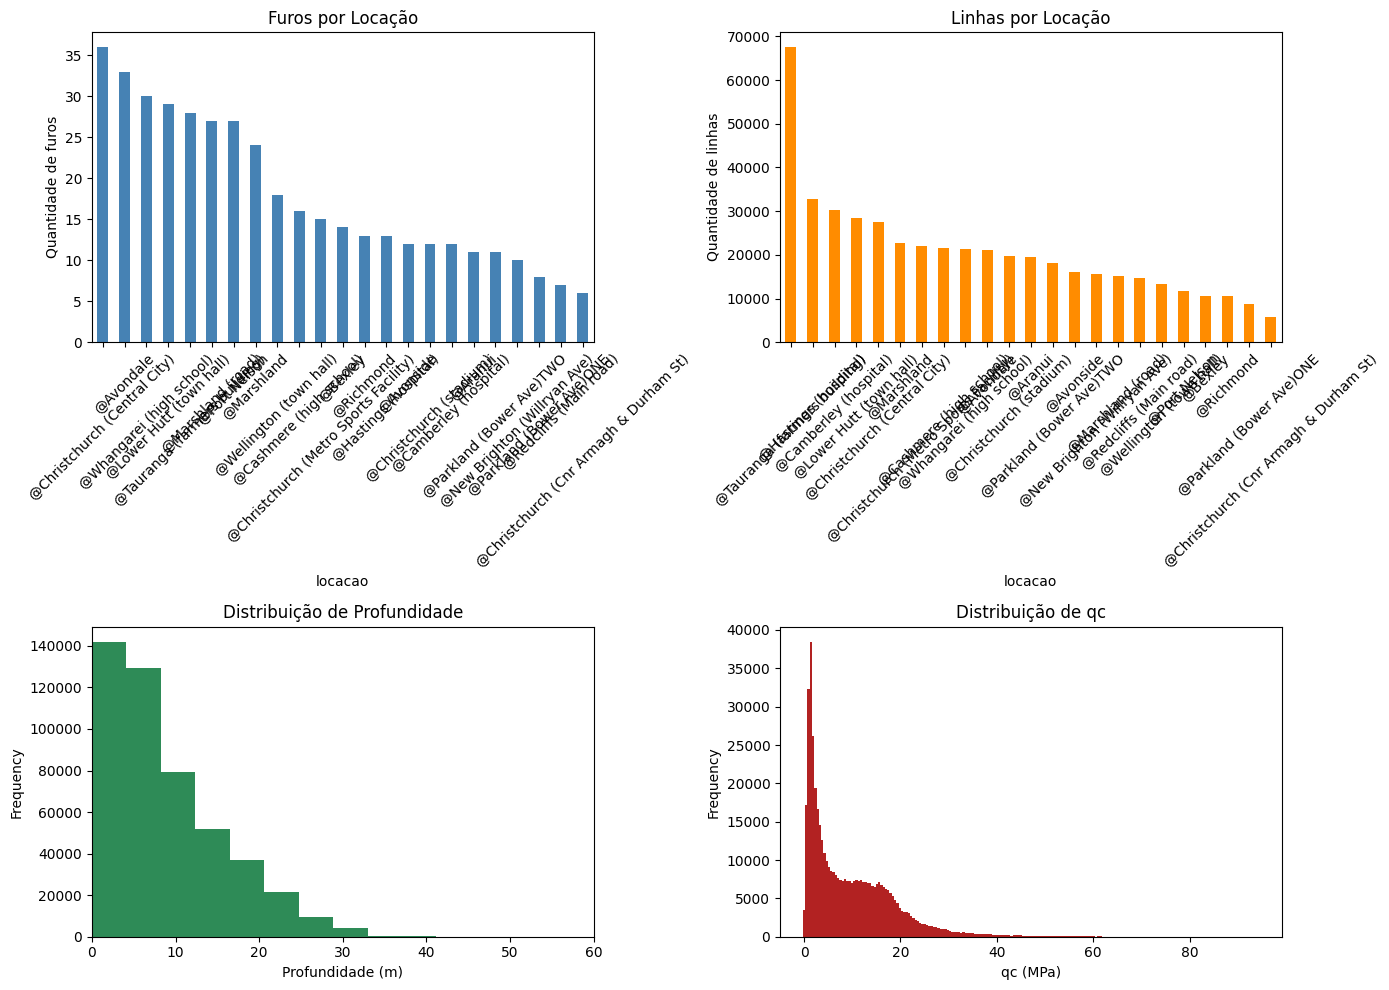


Locações com mais furos:
locacao
@Christchurch (Central City)    36
@Avondale                       33
@Whangarei (high school)        30
@Lower Hutt (town hall)         29
@Tauranga (farmers building)    28
Name: ensaio, dtype: int64

Locações com menos furos:
locacao
@Parkland (Bower Ave)TWO                  11
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Redcliffs (Main road)                     7
@Christchurch (Cnr Armagh & Durham St)     6
Name: ensaio, dtype: int64


In [30]:
# Caminho local após git clone
ARQUIVO = 'cpt-sbt-mvp/data/processed/dataset_compilado.csv'

df = pd.read_csv(ARQUIVO)
print(f'Shape: {df.shape}')
df.head()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Furos por locação ---
furos_por_locacao = df.groupby('locacao')['ensaio'].nunique().sort_values(ascending=False)
furos_por_locacao.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Furos por Locação')
axes[0,0].set_ylabel('Quantidade de furos')
axes[0,0].tick_params(axis='x', rotation=45)

# --- 2. Linhas por locação ---
linhas_por_locacao = df.groupby('locacao').size().sort_values(ascending=False)
linhas_por_locacao.plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Linhas por Locação')
axes[0,1].set_ylabel('Quantidade de linhas')
axes[0,1].tick_params(axis='x', rotation=45)

# --- 3. Distribuição de profundidade ---
df['depth'].plot(kind='hist', bins=200, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Distribuição de Profundidade')
axes[1,0].set_xlabel('Profundidade (m)')
axes[1,0].set_xlim(0,50)


# --- 4. Distribuição de qc ---
df['qc'].plot(kind='hist', bins=200, ax=axes[1,1], color='firebrick')
axes[1,1].set_title('Distribuição de qc')
axes[1,1].set_xlabel('qc (MPa)')
axes[1,0].set_xlim(0,60)


plt.tight_layout()
plt.show()

print(f'\nLocações com mais furos:\n{furos_por_locacao.head()}')
print(f'\nLocações com menos furos:\n{furos_por_locacao.tail()}')

Estratégia de Balanceamento

In [45]:
# ─── PARÂMETROS AJUSTÁVEIS ────────────────────────────────────────────
SEED = 42
# ──────────────────────────────────────────────────────────────────────

# ── Passo 1 — Mediana de furos por locação ────────────────────────────

furos_por_locacao  = df.groupby('locacao')['ensaio'].nunique()
mediana_furos      = int(furos_por_locacao.median())

print(f'Mediana de furos por locação : {mediana_furos}')
print(f'Máximo                       : {furos_por_locacao.max()}')
print(f'Mínimo                       : {furos_por_locacao.min()}')
print()

# Para cada locação, sorteia no máximo mediana_furos furos inteiros
furos_selecionados = (
    df.groupby('locacao')['ensaio']
      .unique()
      .reset_index()
      .apply(lambda row: pd.Series({
          'locacao': row['locacao'],
          'ensaio' : list(row['ensaio'])
                     if len(row['ensaio']) <= mediana_furos
                     else list(
                         pd.Series(row['ensaio'])
                         .sample(mediana_furos, random_state=SEED)
                     )
      }), axis=1)
      .explode('ensaio')
)

df_step1 = df.merge(furos_selecionados, on=['locacao', 'ensaio'])

print(f'Linhas antes  : {len(df):,}')
print(f'Linhas depois : {len(df_step1):,}')
print(f'Furos antes   : {df[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Furos depois  : {df_step1[["locacao","ensaio"]].drop_duplicates().shape[0]}')

Mediana de furos por locação : 14
Máximo                       : 36
Mínimo                       : 6

Linhas antes  : 475,083
Linhas depois : 354,084
Furos antes   : 412
Furos depois  : 283


In [46]:
# ── Passo 2 — Mediana de linhas por furo ─────────────────────────────

linhas_por_furo = df_step1.groupby(['locacao', 'ensaio']).size()
mediana_linhas  = int(linhas_por_furo.median())

print(f'Mediana de linhas por furo : {mediana_linhas}')
print(f'Máximo                     : {linhas_por_furo.max():,}')
print(f'Mínimo                     : {linhas_por_furo.min():,}')
print()

# Limita cada furo individualmente à mediana de linhas
df_step2 = (
    df_step1.groupby(['locacao', 'ensaio'], group_keys=False)
            .apply(lambda x: x.sample(min(len(x), mediana_linhas), random_state=SEED))
            .reset_index(drop=True)
)

print(f'Linhas antes  : {len(df_step1):,}')
print(f'Linhas depois : {len(df_step2):,}')

Mediana de linhas por furo : 1000
Máximo                     : 3,301
Mínimo                     : 49

Linhas antes  : 354,084
Linhas depois : 236,191


RESULTADO FINAL
Total de linhas   : 236,191
Locações          : 23
Furos únicos      : 283
Razão max/min     : 3.28x
Desvio padrão     : 2612


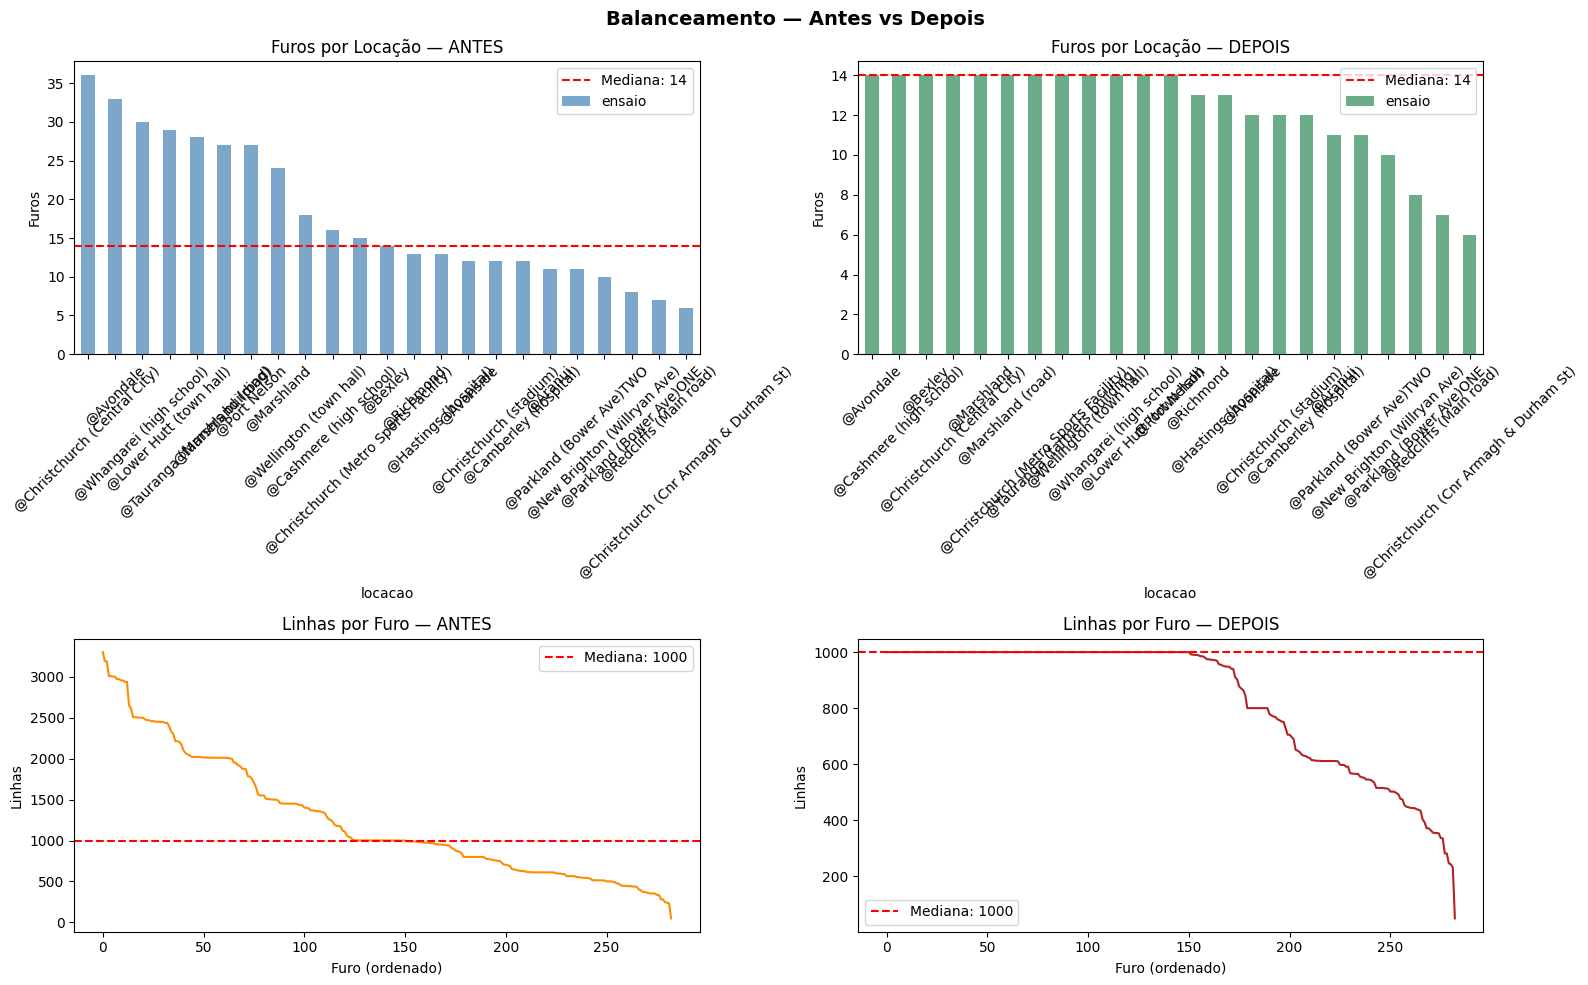

In [47]:
# ── Passo 3 — Resultado final e visualização ──────────────────────────

df_filtrado = df_step2.copy()

locacao_furos  = df_filtrado.groupby('locacao')['ensaio'].nunique()
locacao_linhas = df_filtrado.groupby('locacao').size()

print('=' * 50)
print('RESULTADO FINAL')
print('=' * 50)
print(f'Total de linhas   : {len(df_filtrado):,}')
print(f'Locações          : {df_filtrado["locacao"].nunique()}')
print(f'Furos únicos      : {df_filtrado[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Razão max/min     : {locacao_linhas.max()/locacao_linhas.min():.2f}x')
print(f'Desvio padrão     : {locacao_linhas.std():.0f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Furos por locação — antes
furos_por_locacao.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,0], color='steelblue', alpha=0.7
)
axes[0,0].axhline(y=mediana_furos, color='red', linestyle='--',
                  label=f'Mediana: {mediana_furos}')
axes[0,0].set_title('Furos por Locação — ANTES')
axes[0,0].set_ylabel('Furos')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# Furos por locação — depois
locacao_furos.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,1], color='seagreen', alpha=0.7
)
axes[0,1].axhline(y=mediana_furos, color='red', linestyle='--',
                  label=f'Mediana: {mediana_furos}')
axes[0,1].set_title('Furos por Locação — DEPOIS')
axes[0,1].set_ylabel('Furos')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# Linhas por furo — antes
linhas_por_furo.sort_values(ascending=False).reset_index(drop=True).plot(
    ax=axes[1,0], color='darkorange'
)
axes[1,0].axhline(y=mediana_linhas, color='red', linestyle='--',
                  label=f'Mediana: {mediana_linhas}')
axes[1,0].set_title('Linhas por Furo — ANTES')
axes[1,0].set_xlabel('Furo (ordenado)')
axes[1,0].set_ylabel('Linhas')
axes[1,0].legend()

# Linhas por furo — depois
df_filtrado.groupby(['locacao','ensaio']).size()\
           .sort_values(ascending=False).reset_index(drop=True)\
           .plot(ax=axes[1,1], color='firebrick')
axes[1,1].axhline(y=mediana_linhas, color='red', linestyle='--',
                  label=f'Mediana: {mediana_linhas}')
axes[1,1].set_title('Linhas por Furo — DEPOIS')
axes[1,1].set_xlabel('Furo (ordenado)')
axes[1,1].set_ylabel('Linhas')
axes[1,1].legend()

plt.suptitle('Balanceamento — Antes vs Depois', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Engineering


In [48]:
# Parâmetros físicos
GAMMA   = 18.0   # kN/m³ — peso específico do solo
GAMMA_W = 9.81   # kN/m³ — peso específico da água

# Tensões in situ
df['sigma_v0']     = GAMMA   * df['depth']
df['u0']           = GAMMA_W * df['depth']
df['sigma_v0_eff'] = df['sigma_v0'] - df['u0']
df['delta_u']      = df['u2'] - df['u0']

# Converte qc de MPa para kPa
df['qc_kpa'] = df['qc'] * 1000

# Remove divisores problemáticos
df = df[df['sigma_v0_eff'] > 0].copy()
df = df[(df['qc_kpa'] - df['sigma_v0']) > 0].copy()

# Índices normalizados
df['Qt'] = (df['qc_kpa'] - df['sigma_v0']) / df['sigma_v0_eff']
df['Fr'] = (df['fs'] / (df['qc_kpa'] - df['sigma_v0'])) * 100
df['Bq'] = df['delta_u'] / (df['qc_kpa'] - df['sigma_v0'])

# Clipa para evitar log de valor inválido
df['Fr'] = df['Fr'].clip(lower=0.01)
df['Qt'] = df['Qt'].clip(lower=0.01)

# Índice de Robertson
df['Ic'] = np.sqrt(
    (3.47 - np.log10(df['Qt']))**2 +
    (np.log10(df['Fr']) + 1.22)**2
)

print('Features calculadas: Qt, Fr, Bq, Ic')
print(df[['Qt','Fr','Bq','Ic']].describe().round(3))

Features calculadas: Qt, Fr, Bq, Ic
               Qt          Fr          Bq          Ic
count  474346.000  472247.000  474346.000  472247.000
mean      286.934       1.588       0.021       1.917
std      1376.582      10.238       2.036       0.609
min         0.010       0.010     -21.680       0.028
25%        43.601       0.518      -0.017       1.482
50%       137.799       0.823      -0.005       1.789
75%       256.090       1.779      -0.001       2.331
max    224925.826    2671.276     762.045       7.177


In [ ]:
Classificação de Robertson

In [49]:
def robertson_label(ic):
    if   ic < 1.31: return 7   # Areia densa / cascalho
    elif ic < 2.05: return 6   # Areia limpa
    elif ic < 2.60: return 5   # Areia siltosa
    elif ic < 2.95: return 4   # Silte arenoso
    elif ic < 3.60: return 3   # Argila siltosa
    else:           return 2   # Argila orgânica

NOMES_SBT = {
    2: 'Argila orgânica',
    3: 'Argila siltosa',
    4: 'Silte arenoso',
    5: 'Areia siltosa',
    6: 'Areia limpa',
    7: 'Areia densa'
}

df['SBT']      = df['Ic'].apply(robertson_label)
df['SBT_nome'] = df['SBT'].map(NOMES_SBT)

Balanceamento de Resultados do Modelo de Robertson

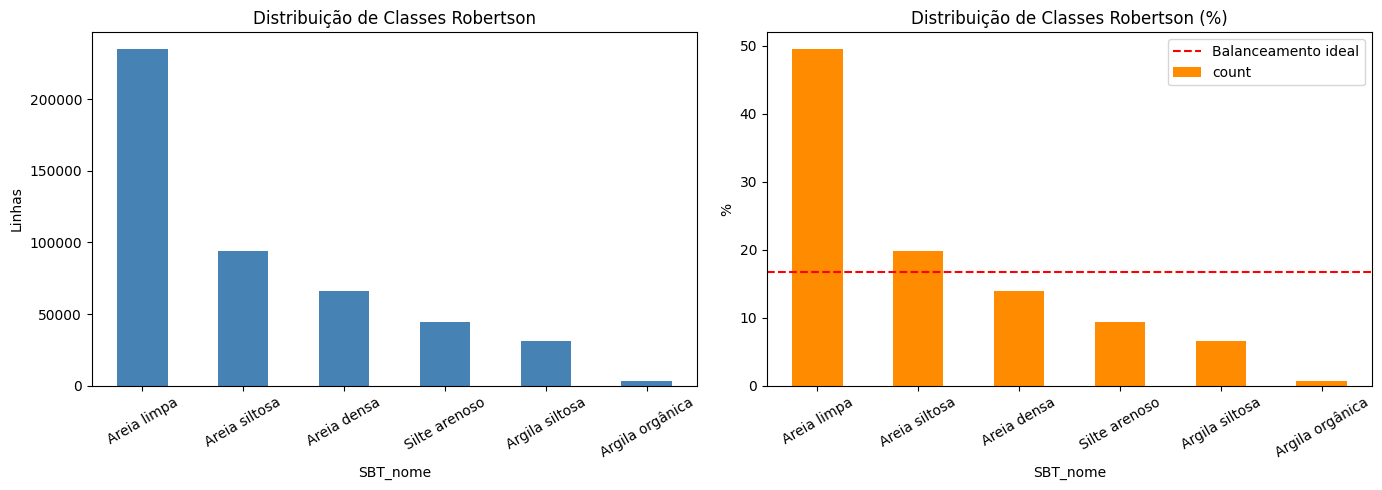


Distribuição por classe:
  Areia limpa           234,859 linhas  (49.5%)
  Areia siltosa          94,265 linhas  (19.9%)
  Areia densa            66,056 linhas  (13.9%)
  Silte arenoso          44,423 linhas  (9.4%)
  Argila siltosa         31,213 linhas  (6.6%)
  Argila orgânica         3,530 linhas  (0.7%)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem = df['SBT_nome'].value_counts()

# Contagem absoluta
contagem.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Classes Robertson')
axes[0].set_ylabel('Linhas')
axes[0].tick_params(axis='x', rotation=30)

# Percentual com linha de balanceamento ideal
(contagem / contagem.sum() * 100).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição de Classes Robertson (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=100/6, color='red', linestyle='--', label='Balanceamento ideal')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nDistribuição por classe:')
for nome, n in contagem.items():
    print(f'  {nome:<20} {n:>8,} linhas  ({n/len(df)*100:.1f}%)')

Normalização Estatística

In [ ]:
from sklearn.preprocessing import StandardScaler

FEATURES = ['Qt', 'Fr', 'Bq', 'Ic']

scaler        = StandardScaler()
df_scaled     = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

print('Após StandardScaler (média ≈ 0, desvio ≈ 1):')
print(df_scaled[FEATURES].describe().round(3))

Exportação

In [ ]:
OUTPUT = 'cpt-sbt-mvp/data/processed/dataset_processado.csv'
df.to_csv(OUTPUT, index=False)

print(f'Exportado para : {OUTPUT}')
print(f'Linhas finais  : {len(df):,}')
print(f'Colunas        : {df.columns.tolist()}')


### 3.1 Análise exploratória resumida (EDA)
**TODO:** inclua gráficos e tabelas essenciais para entender o problema e levantar hipóteses.  
Evite EDA muito extensa — foque no que afeta as decisões de modelagem.


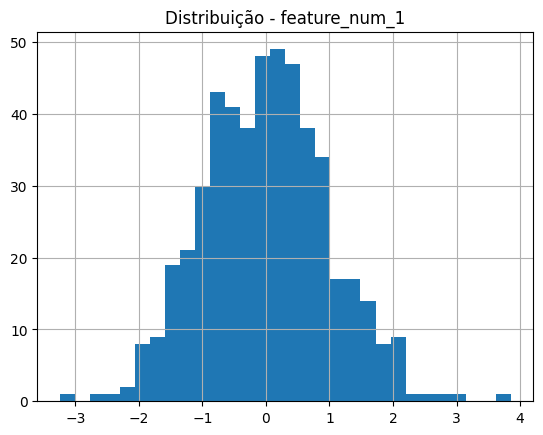

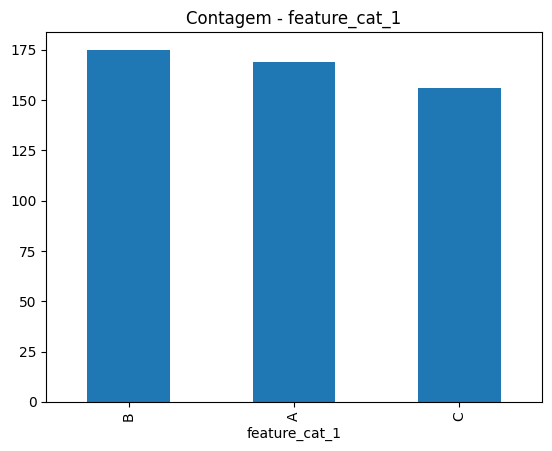

In [ ]:
# Histograma numérico (exemplo)
_ = df["feature_num_1"].hist(bins=30)
plt.title("Distribuição - feature_num_1")
plt.show()

# Contagem categórica (exemplo)
_ = df["feature_cat_1"].value_counts().plot(kind="bar")
plt.title("Contagem - feature_cat_1")
plt.show()



## 4. Definição do target, variáveis e divisão dos dados
**TODO:** escolha o **target** (ou defina a tarefa de clusterização/forecast).  
- Em **séries temporais**, **não embaralhe** e use divisões temporais (ex.: `TimeSeriesSplit`).
- Em **classificação desequilibrada**, considere **estratégias para desbalanceamento** (ex.: `class_weight`, undersampling/oversampling).

> **Atenção:** Todas as **transformações** aprendidas devem ser **ajustadas no treino** e **aplicadas no validação/teste**. Recomendamos usar **pipelines**.


In [ ]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # TODO: ajuste

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "target_clf"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "regressao":
    target = "target_reg"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = [c for c in df.columns if c not in ["target_clf","target_reg","timestamp"]]
elif PROBLEM_TYPE == "serie_temporal":
    target = "target_reg"  # Exemplo
    features = [c for c in df.columns if c not in [target]]
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

PROBLEM_TYPE: classificacao
Target: target_clf
N features: 4
Treino: (400, 4) | Teste: (100, 4)



## 5. Tratamento de dados e **Pipeline** de pré-processamento
Crie um **Pipeline** com as etapas necessárias (limpeza, imputação, encoding, escala, seleção de atributos, etc.)  
Isso garante **reprodutibilidade** e evita **vazamento**.


In [ ]:
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols and c != "timestamp"]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("num_cols:", num_cols[:5], "...")
print("cat_cols:", cat_cols[:5], "...")

num_cols: ['feature_num_1', 'feature_num_2', 'target_reg'] ...
cat_cols: ['feature_cat_1'] ...



## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.


In [ ]:
# === Baselines ===
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])
    candidates = {
        "LogisticRegression": Pipeline([("pre", preprocess), ("model", LogisticRegression(max_iter=200, random_state=SEED))]),
        "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    }
elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", DummyRegressor(strategy="median"))])
    candidates = {
        "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(random_state=SEED))]),
        "RandomForestReg": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    }
elif PROBLEM_TYPE == "clusterizacao":
    # baseline não se aplica diretamente; use um método simples (ex.: KMeans com k fixo) como referência.
    baseline = Pipeline(steps=[("pre", preprocess),
                               ("model", KMeans(n_clusters=3, random_state=SEED))])
    candidates = {
        "KMeans_k3": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=3, random_state=SEED))]),
        "KMeans_k5": Pipeline([("pre", preprocess), ("model", KMeans(n_clusters=5, random_state=SEED))])
    }
elif PROBLEM_TYPE == "serie_temporal":
    # Em séries temporais, a baseline pode ser "naive" (último valor) — aqui, apenas um placeholder.
    # Para modelos clássicos, pode considerar por exemplo Regressores com janelas (feature engineering temporal).
    baseline = None
    candidates = {}
else:
    raise ValueError("PROBLEM_TYPE inválido.")

baseline


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feature_num_1',
                                                   'feature_num_2',
                                                   'target_reg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['feature_cat_1'])])),
                ('model',
                 DummyClassifier(random_state=42, strategy='most_frequent'))])


### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Use **métricas adequadas** ao tipo de problema. Documente suas observações.


In [ ]:
results = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()
    if PROBLEM_TYPE == "classificacao":
        y_pred = baseline.predict(X_test)
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        y_pred = baseline.predict(X_test)
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    # Candidatos
    for name, pipe in candidates.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t1 = time.time()
        if PROBLEM_TYPE == "classificacao":
            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            y_pred = pipe.predict(X_test)
            results[name] = evaluate_regression(y_test, y_pred)
        results[name]["train_time_s"] = round(t1 - t0, 3)

elif PROBLEM_TYPE == "clusterizacao":
    # Baseline e candidatos (ex.: silhouette)
    # Observação: em um projeto real, evite refit em dados de teste fora de validação apropriada.
    results["baseline"] = evaluate_clustering(X_test, baseline)
    for name, pipe in candidates.items():
        results[name] = evaluate_clustering(X_test, pipe)

elif PROBLEM_TYPE == "serie_temporal":
    # TODO: implemente métricas específicas (ex.: MAE/MAPE/RMSE out-of-time)
    results["baseline_naive"] = {"MAE": None, "MAPE": None, "RMSE": None, "obs": "Implementar baseline temporal."}

pd.DataFrame(results).T


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.60,0.450000,0.500000,0.093
LogisticRegression,0.57,0.465415,0.550000,0.095
RandomForest,0.57,0.549299,0.543333,0.728



## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [ ]:
if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestClassifier(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scorer = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "clusterizacao":
    # Clusterização: tuning diferente (ex.: número de clusters). Métricas internas (silhouette) ou externas (se houver rótulos).
    cv = None
    model = Pipeline([("pre", preprocess), ("model", KMeans(random_state=SEED))])
    param_dist = {"model__n_clusters": randint(2, 10)}
    scorer = None

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    # Ex.: usar um regressor com janelas/defasagens previamente criadas
    model = Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))])
    param_dist = {
        "model__n_estimators": randint(100, 300),
        "model__max_depth": randint(3, 15)
    }
    scorer = "neg_mean_absolute_error"

# Executar busca aleatória (exemplo geral — ajuste para seu caso)
if PROBLEM_TYPE != "clusterizacao":
    search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=cv, scoring=scorer, random_state=SEED, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    print("Melhor score (CV):", search.best_score_)
    print("Melhores parâmetros:", search.best_params_)
else:
    print("Para clusterização, avalie k em um range e compare silhouette/indíces de validade. Ex.: varra k de 2 a 10.")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score (CV): 0.5402276617001536
Melhores parâmetros: {'model__max_depth': 14, 'model__min_samples_split': 2, 'model__n_estimators': 148}



## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


              precision    recall  f1-score   support

           0       0.60      0.72      0.65        60
           1       0.39      0.28      0.32        40

    accuracy                           0.54       100
   macro avg       0.50      0.50      0.49       100
weighted avg       0.52      0.54      0.52       100



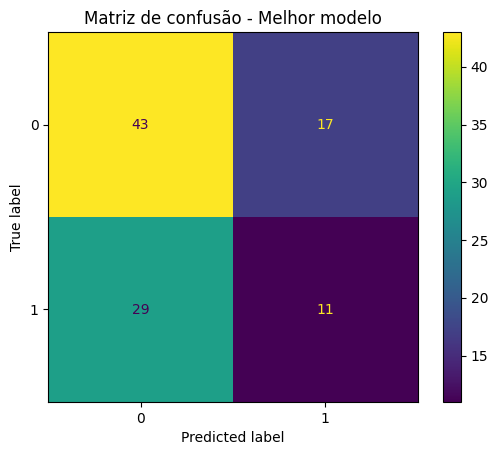

In [ ]:
# Exemplo de re-treino no conjunto de treino+validação (se aplicável) e avaliação no teste

if PROBLEM_TYPE in ["classificacao", "regressao"] and 'search' in globals() and hasattr(search, "best_estimator_"):
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        from sklearn.metrics import classification_report, ConfusionMatrixDisplay
        print(classification_report(y_test, y_pred))
        try:
            ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
            plt.title("Matriz de confusão - Melhor modelo")
            plt.show()
        except Exception as e:
            print("Não foi possível plotar a matriz de confusão:", e)
    else:
        print('Metricas para avaliar a regressão: ', evaluate_regression(y_test, y_pred))
elif PROBLEM_TYPE == "clusterizacao":
    print("Realize análise qualitativa/negócio dos clusters. Visualize centros e perfis.")
elif PROBLEM_TYPE == "serie_temporal":
    print("Avalie métricas fora do tempo; plote série real vs prevista.")


## 9. Engenharia de atributos (detalhe)
**TODO:** Documente as escolhas: seleção/extração, encoding, criação de variáveis temporais (lags, médias móveis), TF-IDF/embeddings (NLP), augmentations (visão), etc.



## 10. (Opcional) Deep Learning / Fine-tuning
Se usar DL, descreva: arquitetura, hiperparâmetros, _early stopping_, tamanho do batch, épocas, e se houve **fine-tuning** de modelos pré-treinados.



## 11. Boas práticas e rastreabilidade
- **Baseline** claro e justificativas para melhorias.  
- **Pipelines** (evitar vazamento).  
- **Decisões de projeto** documentadas (o que tentou e por quê).



## 12. Conclusões e próximos passos
**TODO:** Resuma resultados, trade-offs, e proponha melhorias futuras (mais dados, features, modelos, tuning).



## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  